# Unification

Notebook for example solutions to the nonlinear steady-state warp equations

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 18})

In [2]:
# Load the local |U_perp|-|psi| relation used below.
res = np.load("../../_figures/Q4psi_vs_psi_a0.02_full.npy")

psi_list = res[:, 0]
Q4psi_list = res[:, 1]
Q4psi_lin = res[:, 2]

psi_load = np.hstack(([0], psi_list))
Q4psi_load = np.hstack(([0], Q4psi_list))
psi_crit = psi_list[np.argmax(Q4psi_load)]


def Q4psi_func(psi):
    return np.interp(psi, psi_load, Q4psi_load)


# Fiducial disk model.
R = np.linspace(0.5, 3.0, 401)
dR = R[1] - R[0]
Omega = R**-1.5
H = 0.02 * R**1.5
alpha = 0.0189

Sigma = R**-1.5
f_gap = 1 + 19 * (np.tanh((R - 1) / 0.1) - np.tanh((R - 2) / 0.2))
Sigma /= f_gap


# Shared arrays for the last two figures.
psi_check = np.linspace(0.0001, 2, 4001)
G_levels = np.linspace(0.3, 1.00, 3) * -1.299602269875e-05
sigma = Sigma * H**2 * R**2 * Omega**2
sigma_half = 0.5 * Sigma * H**2 * R**2 * Omega**2

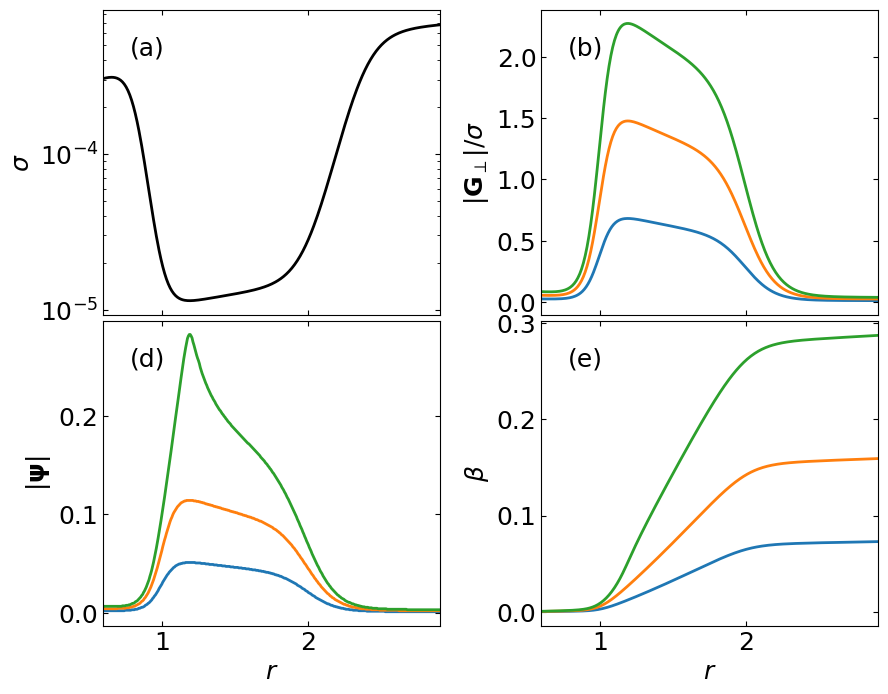

In [3]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=False)
fig.subplots_adjust(hspace=0.02)
fig.subplots_adjust(wspace=0.30)

# Panel (a): sigma vs r
axs[0, 0].semilogy(R, sigma, lw=2, c="k")
axs[0, 0].set_xlim([0.6, 2.9])

# Case-dependent plots
for j, G0 in enumerate(G_levels[:4]):
    Q4psi = G0 / (-0.5 * Sigma * H**2 * R**2 * Omega**2)

    # Panel (b): const/sigma vs r
    axs[0, 1].plot(R, Q4psi, lw=2)

    psi = Q4psi * 0
    for i, Q4psii in enumerate(Q4psi):
        psi[i] = psi_check[np.argmax(Q4psi_func(psi_check) > Q4psii)]

    # Panel (d): psi vs r
    axs[1, 0].plot(R, psi, lw=2)

    # Panel (e): beta vs r
    beta_G = np.cumsum(psi * R * np.gradient(R))
    axs[1, 1].plot(R, beta_G, lw=2)

axs[1, 0].set_xlabel(r"$r$")
axs[1, 1].set_xlabel(r"$r$")

axs[0, 0].set_ylabel(r"$\sigma$")
axs[0, 1].set_ylabel(r"$|{\bf G}_{\perp}|/\sigma$")
axs[1, 0].set_ylabel(r"$|{\bf \psi}|$")
axs[1, 1].set_ylabel(r"$\beta$")

axs[0, 0].text(0.08, 0.85, "(a)", transform=axs[0, 0].transAxes)
axs[0, 1].text(0.08, 0.85, "(b)", transform=axs[0, 1].transAxes)
axs[1, 0].text(0.08, 0.85, "(d)", transform=axs[1, 0].transAxes)
axs[1, 1].text(0.08, 0.85, "(e)", transform=axs[1, 1].transAxes)

for ax in axs.flatten():
    ax.tick_params(
        which="both",
        direction="in",
        top=True,
        bottom=True,
        left=True,
        right=True,
    )

plt.show()

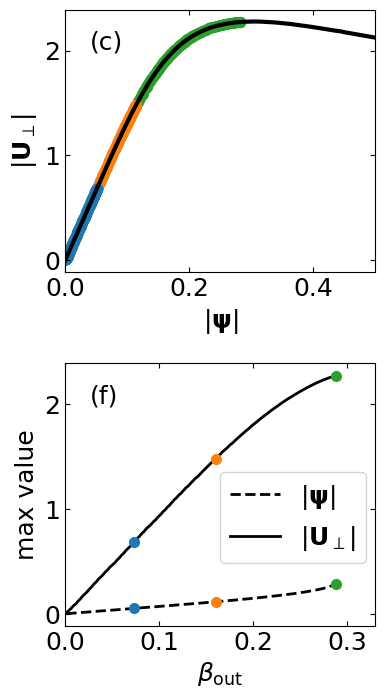

In [4]:
fig, axs = plt.subplots(2, 1, figsize=(4, 8), sharex=False, sharey=False)
fig.subplots_adjust(hspace=0.35)
fig.subplots_adjust(wspace=0.15)

# Case-dependent plots
for j, G0 in enumerate(G_levels[:4]):
    Q4psi = G0 / (-0.5 * Sigma * H**2 * R**2 * Omega**2)

    psi = Q4psi * 0
    for i, Q4psii in enumerate(Q4psi):
        psi[i] = psi_check[np.argmax(Q4psi_func(psi_check) > Q4psii)]

    # Panel (c): |U_perp| vs |psi|
    axs[0].scatter(psi, Q4psi, lw=2, zorder=-j)

    beta_G = np.cumsum(psi * R * np.gradient(R))

    # Panel (f)
    axs[1].scatter(beta_G[-1], np.max(psi), lw=2, zorder=8, c=f"C{j}")
    axs[1].scatter(beta_G[-1], Q4psi_func(np.max(psi)), lw=2, zorder=8, c=f"C{j}")

G_levels_dens = np.linspace(0.001, 1.001, 100) * -1.299602269875e-05
psi_max = G_levels_dens * 0
beta_list = G_levels_dens * 0

for j, G0 in enumerate(G_levels_dens):
    Q4psi = G0 / (-0.5 * Sigma * H**2 * R**2 * Omega**2)
    psi = Q4psi * 0
    for i, Q4psii in enumerate(Q4psi):
        psi[i] = psi_check[np.argmax(Q4psi_func(psi_check) > Q4psii)]
    beta_list[j] = np.cumsum(psi * R * np.gradient(R))[-1]
    psi_max[j] = np.max(np.abs(psi))

axs[1].plot(beta_list, psi_max, lw=2, c="k", ls="--", label=r"$|{\bf \psi}|$")
axs[1].plot(beta_list, Q4psi_func(psi_max), lw=2, c="k", label=r"$|{\bf U}_{\perp}|$")

# Panel (c): |U_perp| vs |psi|
axs[0].plot(psi_check, Q4psi_func(psi_check), c="k", lw=3)
axs[0].set_xlim([0.0, 0.5])
axs[1].set_xlim([0.0, 0.33])

axs[0].set_xlabel(r"$|{\bf \psi}|$")
axs[1].set_xlabel(r"$\beta_{\rm out}$")

axs[0].set_ylabel(r"$|{\bf U}_{\perp}|$")
axs[1].set_ylabel(r"max value")
axs[1].legend(loc=(0.5, 0.24))

axs[0].text(0.08, 0.85, "(c)", transform=axs[0].transAxes)
axs[1].text(0.08, 0.85, "(f)", transform=axs[1].transAxes)

for ax in axs.flatten():
    ax.tick_params(
        which="both",
        direction="in",
        top=True,
        bottom=True,
        left=True,
        right=True,
    )

plt.show()